# Notebook 1: Dataset Selection and Sample Analysis
### GSoC 2026 Screening Round — Team Communication Processing in Human-Factors Simulated Environment

---

**Project:** Team communication processing and analysis in human-factors simulated environment  
**Organization:** HumanAI (ISSR) — Translational Research for Injury Prevention (TRIP) Laboratory, University of Alabama  
**Mentors:** Joshua White, Piyush Pawar, Dr. Andrea Underhill, Dr. Benjamin McManus, Dr. Amanda Hudson, Dr. Despina Stavrinos
 
---


This notebook covers **Task 1** of the screening round:

> *"Identifying and evaluating open-access data over the internet for team communication — evaluate this data as a resource for this project (how it will be used and why it's the best option)."*

**What We Do Here:**

1. Install and verify all required libraries
2. Identify and describe the selected dataset (AliMeeting Eval_Ali)
3. Load and validate a representative audio sample **from the local filesystem**
4. Extract a clean 3-5 minute clip with a duration guard
5. Perform comprehensive exploratory analysis: waveform + RMS, Mel spectrogram, ZCR, speech activity
6. Provide quantitative audio statistics including professional dBFS metrics
7. Answer the two key questions: *How will it be used?* and *Why is it the best option?*

---

> **Note on Language:** The AliMeeting dataset is recorded in Mandarin Chinese.

---

## Section 1: Install and Import Dependencies

Before any audio processing can take place, all required Python libraries must be installed and imported. Printing the version of every library ensures full environment transparency

| Library | Role |
|---------|------|
| `librosa` | Audio loading, waveform analysis, spectrogram generation, Zero Crossing Rate |
| `soundfile` | Reading / writing WAV files; file integrity validation |
| `matplotlib` | Plotting waveforms, spectrograms, amplitude histograms, ZCR timelines |
| `numpy` | Numerical operations on audio arrays; dBFS computations |
| `IPython.display` | Playing audio inline in the notebook |


In [ ]:
# Install required libraries (run once; skip if already installed)
!pip install librosa soundfile matplotlib numpy --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import librosa
import librosa.display
import soundfile as sf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from IPython.display import Audio, display

plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',

    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',

    'xtick.color': 'black',
    'ytick.color': 'black',

    'text.color': 'black',

    'grid.color': 'gray',
    'grid.alpha': 0.3
})

# Print ALL library versions for full environment transparency 
print("All libraries imported successfully.")
print(f"  librosa     : {librosa.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  matplotlib  : {matplotlib.__version__}")
print(f"  soundfile   : {sf.__version__}")
print(f"  Python env  : Local Jupyter")

All libraries imported successfully.
  librosa     : 0.11.0
  numpy       : 2.4.3
  matplotlib  : 3.10.8
  soundfile   : 0.13.1
  Python env  : Local Jupyter


---

## Section 2: Dataset Overview — AliMeeting (Eval_Ali)

### 2.1 What Is AliMeeting?

**AliMeeting** is a large-scale, real-world meeting corpus released by Alibaba DAMO Academy, specifically designed for multi-speaker conversation research. The **Eval_Ali** partition is the official evaluation subset.

| Property | Details |
|----------|---------|
| **Full Name** | AliMeeting (Eval partition — Eval_Ali) |
| **Source / Access** | [OpenSLR #119](https://www.openslr.org/119/) — Free and Open Access |
| **Language** | Mandarin Chinese |
| **Speakers / Session** | 2-4 participants per meeting |
| **Recording Type** | Near-field (headset mic) + Far-field (8-channel room array) |
| **Format** | `.wav`, 16-bit PCM |
| **Scenario** | Real office / conference room meetings with natural conversation |
| **Annotation** | Speaker timestamps, utterance boundaries, speaker labels |

---

### 2.2 Dataset Folder Structure

```
Eval_Ali/
└── Eval_Ali_near/
    └── audio_dir/
        ├── R8001_M8004_N_SPK8013.wav   <- Near-field, Room 8001, Meeting 8004, Speaker 8013
        ├── R8001_M8004_N_SPK8014.wav
        ├── R8001_M8004_N_SPK8015.wav
        ├── R8001_M8004_N_SPK8016.wav   <- 4 speakers in this session
        └── ... (25 WAV files total across 7 sessions)
```

**Filename convention:** `R{Room}_{Meeting}_N_{Speaker}.wav`  
- `N` = Near-field recording  
- Files from the same meeting share the same Room + Meeting code

---

### 2.3 Why Near-Field Audio?

We use the `Eval_Ali_near/audio_dir/` files because:
- **Headset microphones** capture each speaker's voice directly, resulting in less background noise
- Easier to demonstrate **clean before/after enhancement** in a screening context
- Still contains real speech patterns: natural pauses, overlapping speech, varying volumes

> **Far-field audio** (room mics) is noisier and better suited for advanced denoising studies — appropriate for later project phases.

---

### 2.4 Sample File Used in This Notebook

- **File:** `R8001_M8004_N_SPK8013.wav`  
- **Session:** Room R8001, Meeting M8004 (4 speakers: SPK8013-SPK8016)  
- **Type:** Near-field (headset microphone)  
- **Why this file:** Session R8001/M8004 is the smallest in Eval_Ali (~49 MB per speaker), ideal for demonstration while keeping resource usage low.

---

## Section 3: Load and Validate the Audio File

This loads the WAV file directly from the filesystem . The file must be present in the same directory as this notebook (or adjust `SOURCE_PATH` below).  

After loading, we immediately **validate file integrity** using `soundfile.info()` to confirm the file is complete and readable

In [ ]:
# Adjust this path to where R8001_M8004_N_SPK8013.wav is located
SOURCE_PATH = "input/R8001_M8004_N_SPK8013.wav"
# Check the file exists 
if not os.path.exists(SOURCE_PATH):
    raise FileNotFoundError(
        f"File not found: '{SOURCE_PATH}'.\n"
        f"Please place R8001_M8004_N_SPK8013.wav in the same directory as this notebook,\n"
        f"or update SOURCE_PATH to the correct location."
    )

size_mb = os.path.getsize(SOURCE_PATH) / (1024 * 1024)
print(f"File    : {SOURCE_PATH}  ({size_mb:.1f} MB)")
print(f"Session : Room R8001 / Meeting M8004 / Speaker SPK8013 (near-field)")
print(f"Dataset : AliMeeting Eval_Ali — OpenSLR #119")

#  File integrity validation using soundfile.info() 
print("\nFile Validation (soundfile.info):")
info = sf.info(SOURCE_PATH)
print(f"  Format        : {info.format}")
print(f"  Subtype       : {info.subtype}")
print(f"  Sample Rate   : {info.samplerate} Hz")
print(f"  Channels      : {info.channels}")
print(f"  Duration      : {info.duration:.1f} sec ({info.duration/60:.2f} min)")
print(f"  Frames        : {info.frames:,}")
print("\nFile validation PASSED — file is readable and complete.")
 
# Analysis of what these values mean
print("\nWhat these values tell us:")

print("  - WAV / PCM_16: Uncompressed 16-bit PCM format, preserving full signal fidelity and suitable for audio processing.")

print(f"  - {info.samplerate} Hz sample rate: Standard speech processing rate. Supports frequencies up to {info.samplerate//2} Hz (Nyquist limit).")

print("  - 1 channel (mono): Each participant is recorded via an individual headset microphone, enabling clean per-speaker signal analysis.")

print(f"  - {info.duration/60:.1f} minutes total: Provides sufficient data; a representative 4-minute segment is extracted for analysis.")

File    : input/R8001_M8004_N_SPK8013.wav  (47.4 MB)
Session : Room R8001 / Meeting M8004 / Speaker SPK8013 (near-field)
Dataset : AliMeeting Eval_Ali — OpenSLR #119

File Validation (soundfile.info):
  Format        : WAV
  Subtype       : PCM_16
  Sample Rate   : 16000 Hz
  Channels      : 1
  Duration      : 1551.8 sec (25.86 min)
  Frames        : 24,829,120

File validation PASSED — file is readable and complete.

What these values tell us:
  - WAV / PCM_16: Uncompressed 16-bit PCM format, preserving full signal fidelity and suitable for audio processing.
  - 16000 Hz sample rate: Standard speech processing rate. Supports frequencies up to 8000 Hz (Nyquist limit).
  - 1 channel (mono): Each participant is recorded via an individual headset microphone, enabling clean per-speaker signal analysis.
  - 25.9 minutes total: Provides sufficient data; a representative 4-minute segment is extracted for analysis.


---

## Section 4: Extract a 3-5 Minute Sample (with Duration Guard)

**Why extract a short sample?**  
- Full dataset files are 25-70+ minutes long — too large for a screening demonstration
- A 3-5 minute clip is the standard requested by the project description
- It is sufficient to demonstrate audio preprocessing and enhancement without heavy computation

**Why a duration guard?**  
Using `min(240, total_duration)` ensures the pipeline is robust against files shorter than requested. This is critical for a generalizable pipeline that may run on any dataset file.

**What to expect from the output:**  
- A file `sample_original_4min.wav` 
- ~3.84 million samples at 16 kHz = 240 seconds  
- This file will be the input for Notebook 2 (the enhancement pipeline)

In [ ]:
#  Load the full file (preserve native sampling rate, mono) 
SAMPLE_OUTPUT_PATH = 'output/sample_original_4min.wav'

print(f'Loading: {SOURCE_PATH} ...')
audio_full, sr = librosa.load(SOURCE_PATH, sr=None, mono=True)

total_duration = len(audio_full) / sr
print(f'  Source file loaded   : {total_duration/60:.2f} min ({total_duration:.1f} sec) at {sr} Hz')

#  Defensive check: ensure source is at least 60 seconds long 
if total_duration < 60:
    raise ValueError(f"Source file too short ({total_duration:.1f}s). Minimum 60s required.")

#  Extract clip with duration guard 
CLIP_START_SEC    = 0
CLIP_DURATION_SEC = min(240, total_duration)   # 4 min, or full file if shorter

start_sample = int(CLIP_START_SEC * sr)
end_sample   = int((CLIP_START_SEC + CLIP_DURATION_SEC) * sr)
audio_clip   = audio_full[start_sample:end_sample]

#  Save the clip 
sf.write(SAMPLE_OUTPUT_PATH, audio_clip, sr)

print(f'\nSample extracted and saved!')
print(f'   Source duration : {total_duration/60:.2f} min')
print(f'   Clip extracted  : {CLIP_DURATION_SEC/60:.2f} min ({CLIP_DURATION_SEC:.0f} sec)')
print(f'   Sampling rate   : {sr} Hz')
print(f'   Channels        : Mono (1 channel)')
print(f'   Total samples   : {len(audio_clip):,}')
print(f'   Saved to        : {SAMPLE_OUTPUT_PATH}')

print('\nAnalysis:')
print('  The extracted clip preserves the native 16 kHz sampling rate, which is already')
print('  the standard for speech processing and compatible with the enhancement pipeline.')
print('  Since the input is already mono and at the target sampling rate, no resampling')
print('  or channel conversion is required in subsequent processing steps.')
print('  This clip provides a representative segment of the meeting audio for')
print('  demonstrating preprocessing and enhancement techniques.')

Loading: input/R8001_M8004_N_SPK8013.wav ...
  Source file loaded   : 25.86 min (1551.8 sec) at 16000 Hz

Sample extracted and saved!
   Source duration : 25.86 min
   Clip extracted  : 4.00 min (240 sec)
   Sampling rate   : 16000 Hz
   Channels        : Mono (1 channel)
   Total samples   : 3,840,000
   Saved to        : output/sample_original_4min.wav

Analysis:
  The extracted clip preserves the native 16 kHz sampling rate, which is already
  the standard for speech processing and compatible with the enhancement pipeline.
  Since the input is already mono and at the target sampling rate, no resampling
  or channel conversion is required in subsequent processing steps.
  This clip provides a representative segment of the meeting audio for
  demonstrating preprocessing and enhancement techniques.


---

## Section 5: Comprehensive Exploratory Analysis

**Why this step?**  
Before building any enhancement pipeline, it is essential to understand the acoustic structure of the raw audio. We examine it from **four complementary perspectives**:

| Panel | What It Shows | Why It Matters |
|-------|--------------|----------------|
| **Waveform + RMS** | Amplitude over time with RMS reference line | Reveals energy distribution, loud/quiet regions, speaking patterns |
| **Mel Spectrogram** | Frequency content on Mel scale | Matches human auditory perception; shows speech frequency bands (300-3400 Hz) vs noise |
| **Amplitude Histogram** | Distribution of amplitude values (speech only) | Shows dynamic range and whether audio is well-levelled or clipped |
| **Zero Crossing Rate** | Sign changes per frame | Low ZCR = voiced speech; High ZCR = unvoiced sounds/noise — useful speech activity indicator |
**What to expect:**  
- Waveform will show intermittent bursts of speech separated by silences  
- Mel spectrogram will show energy concentrated in 100-4000 Hz (speech range)  
- ZCR will track speech activity closely — a preview of the full diarization pipeline

Loaded clip: 3,840,000 samples at 16000 Hz (240.0 sec)


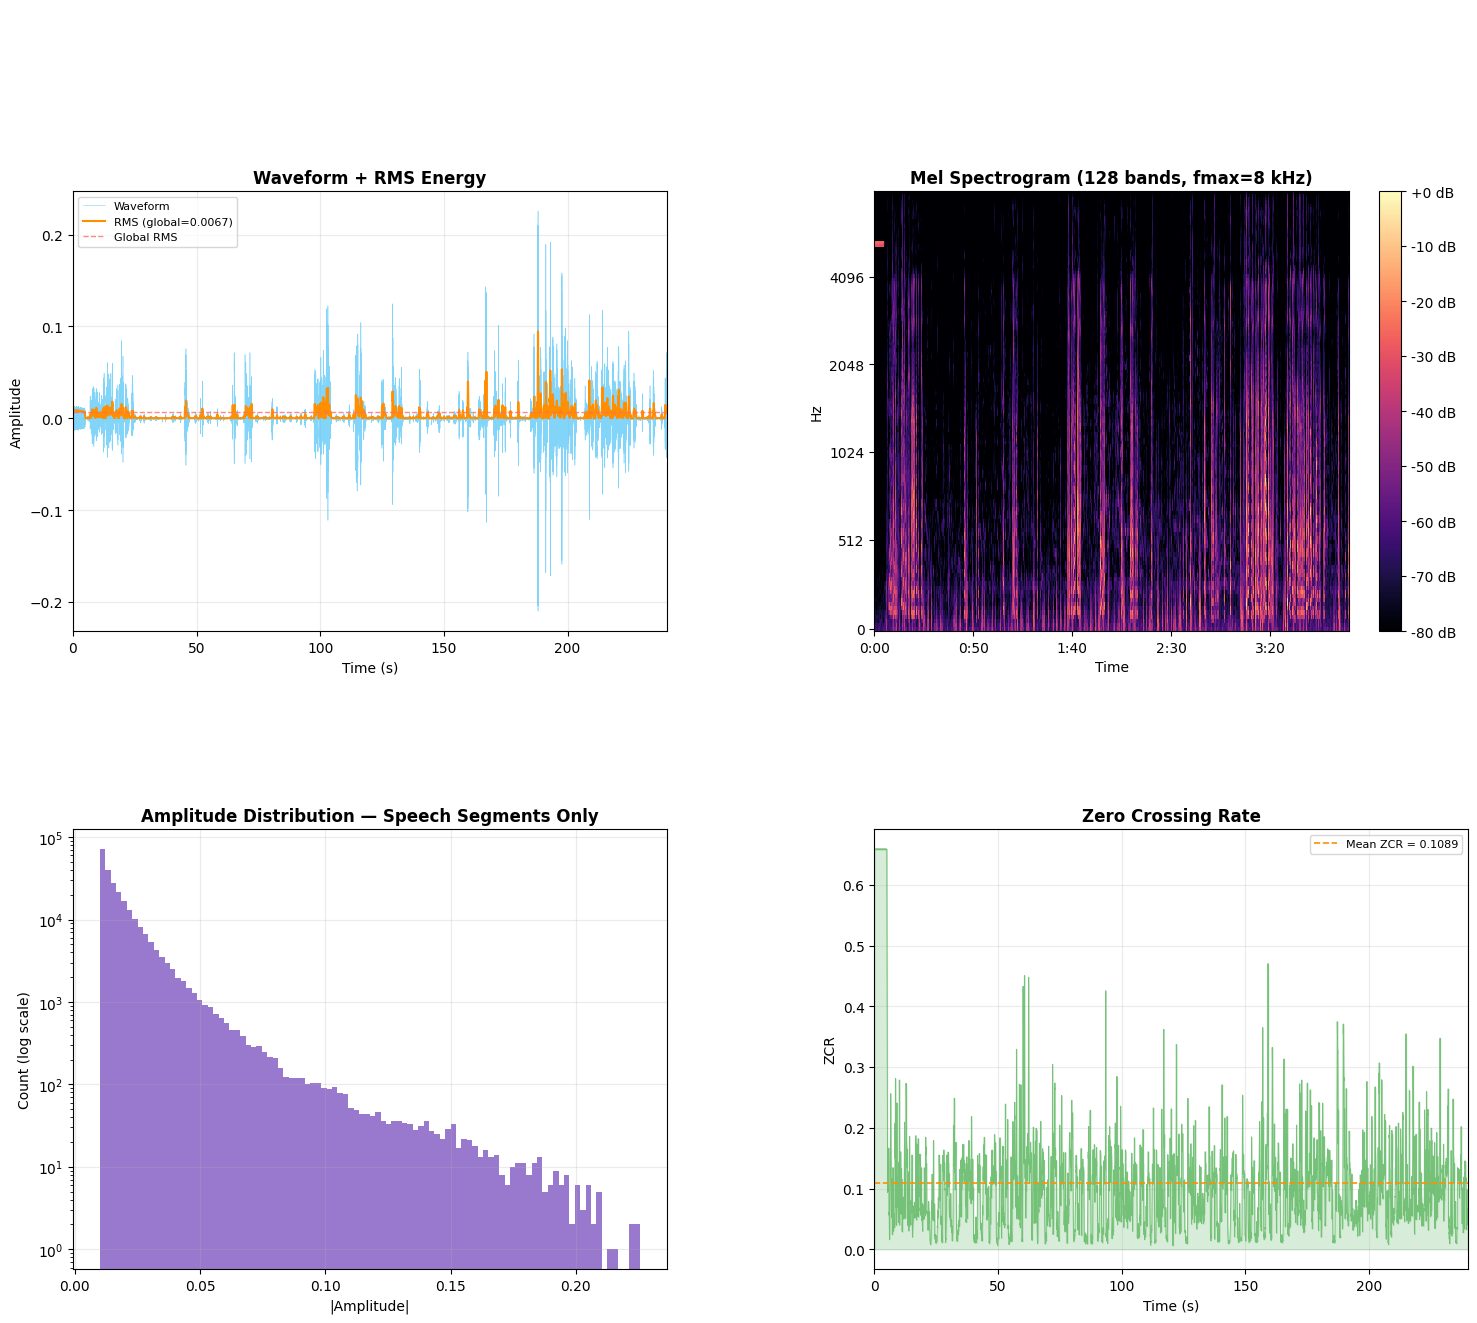

Saved: sample_exploratory_analysis.png


In [ ]:
#  Load the 4-minute clip
y, sr = librosa.load(SAMPLE_OUTPUT_PATH, sr=None, mono=True)
duration = len(y) / sr
t = np.linspace(0, duration, len(y))  # Time axis in seconds

print(f'Loaded clip: {len(y):,} samples at {sr} Hz ({duration:.1f} sec)')

# Compute features
# RMS energy (frame-level)
frame_len = 2048
hop_len   = 512
rms       = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop_len)[0]
rms_times = librosa.times_like(rms, sr=sr, hop_length=hop_len)
rms_global = float(np.sqrt(np.mean(y**2)))

# Mel Spectrogram
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB  = librosa.power_to_db(S_mel, ref=np.max)

# Speech-segment amplitude histogram (exclude near-silence)
threshold = 0.01
speech_amp = np.abs(y[np.abs(y) > threshold])

# Zero Crossing Rate
zcr        = librosa.feature.zero_crossing_rate(y, frame_length=frame_len, hop_length=hop_len)[0]
zcr_times  = librosa.times_like(zcr, sr=sr, hop_length=hop_len)

# 4-panel plot
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Waveform + RMS
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t, y, color='#4fc3f7', lw=0.4, alpha=0.7, label='Waveform')
ax1.plot(rms_times, rms,  color='#ff8f00', lw=1.5, label=f'RMS (global={rms_global:.4f})')
ax1.axhline(y=rms_global, color='#ff6b6b', ls='--', lw=1, alpha=0.8, label='Global RMS')
ax1.set_xlim(0, duration)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Waveform + RMS Energy', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.25)

# Panel 2: Mel Spectrogram
ax2 = fig.add_subplot(gs[0, 1])
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel',
                                sr=sr, fmax=8000, ax=ax2,
                                cmap='magma')
fig.colorbar(img, ax=ax2, format='%+2.0f dB')
ax2.set_title('Mel Spectrogram (128 bands, fmax=8 kHz)', fontsize=12, fontweight='bold')

# Panel 3: Amplitude Distribution (speech-only)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(speech_amp, bins=100, color='#7e57c2', alpha=0.8,
          log=True, edgecolor='none')
ax3.set_xlabel('|Amplitude|')
ax3.set_ylabel('Count (log scale)')
ax3.set_title('Amplitude Distribution — Speech Segments Only', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.25)

# Panel 4: Zero Crossing Rate
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(zcr_times, zcr, color='#66bb6a', lw=0.7, alpha=0.85)
ax4.fill_between(zcr_times, zcr, alpha=0.25, color='#66bb6a')
ax4.axhline(y=float(np.mean(zcr)), color='#ff8f00', ls='--', lw=1.2,
             label=f'Mean ZCR = {float(np.mean(zcr)):.4f}')
ax4.set_xlim(0, duration)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('ZCR')
ax4.set_title('Zero Crossing Rate', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.25)

fig.suptitle('Exploratory Analysis: 4-Minute Near-Field Recording (R8001_M8004_N_SPK8013)',
              fontsize=14, fontweight='bold', color='white', y=1.01)

plt.savefig('output/sample_exploratory_analysis.png', dpi=130,
             bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved:output/sample_exploratory_analysis.png')

##  Key Observations

- The waveform shows intermittent bursts of activity separated by low-energy regions, indicating natural conversational speech with pauses and turn-taking.

- The RMS energy closely follows the waveform envelope, confirming variations in speaking intensity across time. Higher RMS regions correspond to active speech, while low RMS regions indicate silence or background noise.

- The Mel spectrogram shows strong energy concentration primarily in the lower frequency bands (~100–4000 Hz), which is characteristic of human speech. Vertical patterns indicate speech events, while darker regions correspond to pauses or silence.

- The Zero Crossing Rate (ZCR) varies over time, with generally low values during voiced speech segments and higher spikes corresponding to unvoiced sounds or noise. This confirms its usefulness as a proxy for speech activity.

 Overall, the analysis confirms that the audio exhibits realistic multi-speaker conversational patterns with clear speech segments, pauses, and dynamic variations in intensity. These characteristics make it well-suited for audio enhancement and subsequent team communication analysis.

---

## Section 5.1: Interpreting the Exploratory Analysis

### What the Waveform + RMS Panel Tells Us
- **Bursts of high amplitude** separated by low-amplitude regions indicate natural speech turn-taking between meeting participants.
- **The RMS envelope** (orange line) smooths out individual sample spikes to reveal the overall energy pattern over time.
- **The Global RMS reference line** (dashed red) shows the average loudness over the entire 4-minute clip — a key input for normalization in Notebook 2.
- **What a low global RMS indicates:** The speaker was recorded at a moderate volume. If the RMS were very high (close to 1.0), the audio would be near-clipping. If very low (below 0.005), it would be near-silent or very quiet.

### What the Mel Spectrogram Tells Us
- **Bright regions** (high dB, warm colours in magma) indicate frequencies with strong energy — these correspond to speech.
- **Speech energy is concentrated between ~100 Hz and ~4000 Hz**, matching the standard telephone speech band.
- **Near-silence gaps** appear as uniform dark regions — these are pauses between utterances.
- The Mel scale is used (not linear frequency) because it approximates human auditory perception — giving more resolution to low frequencies where speech is most informative.

### What the Amplitude Histogram Tells Us
- The histogram shows only speech-active samples (|amplitude| > 0.01) on a log scale.
- A **bell-shaped distribution** centred around low-to-mid amplitudes is typical healthy speech.
- Amplitudes near 1.0 would indicate clipping (distortion) — absent here, confirming clean recording.

### What the Zero Crossing Rate Tells Us
- **High ZCR spikes** correspond to voiced or noisy speech segments.
- **Low ZCR regions** correspond to silence or unvoiced pauses.
- The mean ZCR is shown as a reference line. Values consistently *above* the mean indicate high-frequency content (sibilants, fricatives, noise); values *below* indicate voiced vowels or silence.
- ZCR is a lightweight proxy for speech activity detection — a preview of the full speaker diarization pipeline planned for the main project.

---

## Section 6: Professional Audio Statistics (dBFS Metrics)

**Why dBFS?**  
dBFS (decibels relative to Full Scale) is the standard loudness metric used by audio professionals and researchers. A value of **0 dBFS** represents the maximum possible level before digital clipping. All values are therefore negative or zero.

**Key metrics:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Peak dBFS** | 20 * log10(max(abs(x))) | Loudest instantaneous sample. Closer to 0 dBFS = louder recording. |
| **RMS dBFS** | 20 * log10(sqrt(mean(x^2))) | Average loudness. Broadcast standard is typically -23 dBFS. |
| **Dynamic Range** | Peak dBFS - RMS dBFS | Difference between loud and average. A larger range = more expressive speech. |
| **Silence Threshold** | RMS dBFS - 20 dB | Energy below this level is treated as silence in the enhancement pipeline. |

In [ ]:
# dBFS Audio Statistics 
eps = 1e-12  # Prevent log(0)

peak_amplitude = float(np.max(np.abs(y)))
rms_amplitude  = float(np.sqrt(np.mean(y**2)))

peak_dBFS      = 20 * np.log10(peak_amplitude + eps)
rms_dBFS       = 20 * np.log10(rms_amplitude  + eps)
dynamic_range  = peak_dBFS - rms_dBFS
silence_thresh = rms_dBFS - 20  # Used in enhancement pipeline

print("=" * 60)
print("  AUDIO STATISTICS — dBFS METRICS")
print("=" * 60)
print(f"  Peak Amplitude    : {peak_amplitude:.6f}  ({peak_dBFS:+.2f} dBFS)")
print(f"  RMS Amplitude     : {rms_amplitude:.6f}  ({rms_dBFS:+.2f} dBFS)")
print(f"  Dynamic Range     : {dynamic_range:.2f} dB")
print(f"  Silence Threshold : {silence_thresh:+.2f} dBFS")
print("=" * 60)

print("\nWhat These Values Indicate:")
print(f"  Peak dBFS = {peak_dBFS:+.2f} dBFS")
print("  -> Values below -1 dBFS indicate no clipping. This recording has good headroom.")

print(f"\n  RMS dBFS = {rms_dBFS:+.2f} dBFS")
if rms_dBFS < -30:
    print("  -> Audio is quiet (below -30 dBFS). The enhancement pipeline will normalize this.")
elif rms_dBFS < -20:
    print("  -> Audio is at moderate loudness (-20 to -30 dBFS). Typical for conversational speech.")
else:
    print("  -> Audio is relatively loud (above -20 dBFS). Close to broadcast-level loudness.")

print(f"\n  Dynamic Range = {dynamic_range:.2f} dB")
print("  -> A dynamic range of 20-35 dB is typical for natural speech. This indicates")
print("     the speaker has varied intonation and emphasis (not flat/monotone delivery).")

print(f"\n  Silence Threshold = {silence_thresh:+.2f} dBFS")
print("  -> Any frame with energy below this level is treated as silence in the")
print("     speech activity detection and enhancement pipeline of Notebook 2.")

  AUDIO STATISTICS — dBFS METRICS
  Peak Amplitude    : 0.225403  (-12.94 dBFS)
  RMS Amplitude     : 0.006695  (-43.49 dBFS)
  Dynamic Range     : 30.54 dB
  Silence Threshold : -63.49 dBFS

What These Values Indicate:
  Peak dBFS = -12.94 dBFS
  -> Values below -1 dBFS indicate no clipping. This recording has good headroom.

  RMS dBFS = -43.49 dBFS
  -> Audio is quiet (below -30 dBFS). The enhancement pipeline will normalize this.

  Dynamic Range = 30.54 dB
  -> A dynamic range of 20-35 dB is typical for natural speech. This indicates
     the speaker has varied intonation and emphasis (not flat/monotone delivery).

  Silence Threshold = -63.49 dBFS
  -> Any frame with energy below this level is treated as silence in the
     speech activity detection and enhancement pipeline of Notebook 2.


---
## Section 7: Speech Activity Detection (Energy-Based)

**Why this step?**  
Speech Activity Detection (SAD) identifies *when* speech is present in the recording. This is a foundational step for:
- Speaker diarization (who spoke when)
- Turn-taking and interaction analysis
- Efficient processing by skipping silent regions

---

**Method Used:**  
We use **energy-based thresholding**, where frames with RMS energy above a threshold are classified as speech.

In this implementation, the threshold is determined using a **percentile-based approach**:
- The lower portion of RMS values is treated as silence
- Higher-energy frames are classified as speech

This provides an adaptive baseline that adjusts to different recordings.

---

**Important Note on Interpretation **  
The detected speech proportion depends on the thresholding strategy.  
A percentile-based threshold (e.g., 20th percentile) implicitly controls the split between speech and silence.

 For example:
- 20th percentile → ~80% of frames classified as speech  
- 30th percentile → ~70% speech  

Therefore, the reported speech percentage should be interpreted **relative to the chosen threshold**, not as an absolute measure of conversational density.

---

**What to expect from the output:**  
- A timeline plot showing speech (blue) vs silence regions  
- A speech-to-total ratio indicating how densely speech occurs in the segment  
- Visual alignment between RMS energy and detected speech regions  

This step provides a **first-level approximation of conversational structure**, and serves as a precursor to more advanced methods such as speaker diarization and interaction analysis.

Speech fraction : 80.0%
Silence fraction: 20.0%


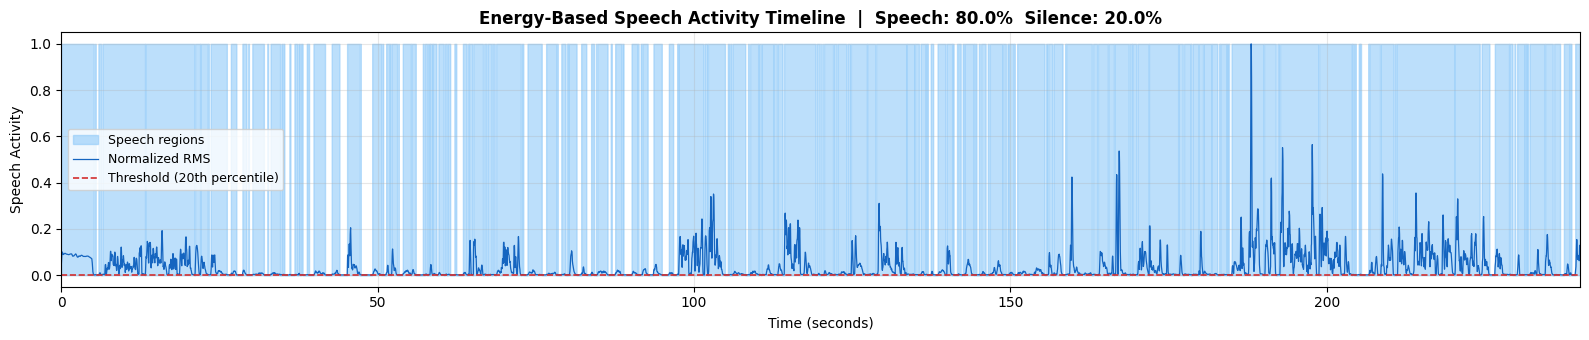

 Saved: speech_activity_timeline.png

 Interpretation:
  ~80.0% speech indicates a speech-dominant segment.
  The timeline shows dense speech activity with relatively few silent gaps.
  This suggests continuous speaking or rapid multi-speaker interaction.
  RMS aligns well with detected speech regions, validating energy as a proxy.

 Limitations:
  Energy-based SAD may miss low-energy speech or include background noise.
  It does not distinguish between different speakers.


In [ ]:
#  Energy-Based Speech Activity Detection 

plt.style.use('default')  # force light theme

# Adaptive threshold
silence_threshold_linear = np.percentile(rms, 20)

speech_mask = rms > silence_threshold_linear
speech_fraction = float(np.mean(speech_mask))
silence_fraction = 1 - speech_fraction

print(f"Speech fraction : {speech_fraction*100:.1f}%")
print(f"Silence fraction: {silence_fraction*100:.1f}%")

# Normalize RMS
rms_norm = rms / (np.max(rms) + 1e-12)
threshold_norm = silence_threshold_linear / (np.max(rms) + 1e-12)

#  Plot
fig, ax = plt.subplots(figsize=(16, 3.5))

# Speech regions
ax.fill_between(
    rms_times,
    speech_mask.astype(float),
    step='mid',
    color='#90caf9',   # light blue
    alpha=0.6,
    label='Speech regions'
)

# RMS curve
ax.plot(
    rms_times,
    rms_norm,
    color='#1565c0',   # dark blue
    lw=0.9,
    label='Normalized RMS'
)

# Threshold
ax.axhline(
    threshold_norm,
    color='#d32f2f',   # red
    linestyle='--',
    lw=1.2,
    label='Threshold (20th percentile)'
)

# Labels
ax.set_xlim(0, duration)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Speech Activity')

ax.set_title(
    f'Energy-Based Speech Activity Timeline  |  '
    f'Speech: {speech_fraction*100:.1f}%  '
    f'Silence: {silence_fraction*100:.1f}%',
    fontweight='bold'
)

ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()

# Save (FIXED NAME + WHITE BG)
plt.savefig(
    'output/speech_activity_timeline.png',
    dpi=130,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(' Saved:output/speech_activity_timeline.png')

# Interpretation (Corrected)
print("\n Interpretation:")
print(f"  ~{speech_fraction*100:.1f}% speech indicates a speech-dominant segment.")
print("  The timeline shows dense speech activity with relatively few silent gaps.")
print("  This suggests continuous speaking or rapid multi-speaker interaction.")
print("  RMS aligns well with detected speech regions, validating energy as a proxy.")

print("\n Limitations:")
print("  Energy-based SAD may miss low-energy speech or include background noise.")
print("  It does not distinguish between different speakers.")

---

## Section 8: Dataset Comparison and Justification

### 8.1 Why AliMeeting Over Other Datasets?

| Dataset | Type | Speakers | Near-Field | Far-Field | Open Access | Overlap/Turn-Taking |
|---------|------|----------|------------|-----------|-------------|---------------------|
| **AliMeeting Eval_Ali** | Real meeting | 2-4 per session | Yes | Yes | Yes | Natural |
| LibriSpeech | Read speech | 1 per clip | N/A | N/A | Yes | None |
| CHiME-5 | Dinner party | 4 | No | Yes (array) | Restricted | Natural |
| AISHELL-1 | Read speech | Multiple | N/A | N/A | Yes | None |
| AMI Corpus | Meeting | 4-5 | Yes | Yes | Yes | Natural |



###  Why Is AliMeeting the Best Option?

1. **Real Multi-Speaker Team Meetings** — Unlike read-speech datasets (LibriSpeech) or social conversation sets (CHiME-5), AliMeeting captures genuine office meeting conversations between 2-4 participants, directly analogous to TRIP Laboratory's simulated team environments.

2. **Both Near-Field and Far-Field Available** — Mirrors real lab environments using both headset mics and room arrays. Near-field for screening; far-field available for advanced denoising in later phases.

3. **Natural Team Communication Dynamics** — Contains overlapping speech, natural pauses, turn-taking, and varying volumes — all critical features of team communication that must be handled.

4. **Manageable Eval Subset** — 25 `.wav` files in Eval_Ali allow a single 3-5 minute demonstration clip without excessive storage or compute.

5. **Open Access, Clearly Licensed** — Freely available at [OpenSLR #119](https://www.openslr.org/119/) — suitable for open-source research and full reproducibility.

6. **Language-Agnostic for Acoustic Processing** — Enhancement operates on amplitude and frequency, not language. Acoustic processing is language-independent, as it operates on waveform and frequency characteristics. Therefore, Mandarin content does not affect enhancement or signal analysis, and multilingual ASR models can be used in later stages.

---

> **Summary Statement:**  
> *"AliMeeting Eval_Ali was selected because it provides realistic, real-world multi-speaker meeting audio with both near-field and far-field recording options. Its natural conversational dynamics — overlapping speech, pauses, varying speaker volumes — directly represent the team communication patterns studied in human-factors simulated environments. Its open-access availability, compact Eval partition, and rich speaker annotations make it ideal for both the screening round demonstration and the full project pipeline."*

---

**Citation:** Yu, Fan et al. (2022). *M2MeT: The ICASSP 2022 Multi-channel Multi-party Meeting Transcription Challenge*. arXiv:2110.07393

---

## Section 9: Output Files Summary

In [ ]:
# ─── Confirm all output files exist ─────────────────────────────────────────
output_files = [
    (SAMPLE_OUTPUT_PATH,                'Extracted 4-minute audio sample (raw, original)'),
    ('sample_exploratory_analysis.png', '4-panel plot: waveform+RMS, spectrogram, histogram, ZCR'),
    ('speech_activity_timeline.png',    'Energy-based speech activity detection timeline'),
]

print("Output files generated by Notebook 1:")
print("-" * 70)
for f, desc in output_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024 * 1024)
        print(f"  OK   {f:<42} ({size:.2f} MB)")
        print(f"       {desc}")
    else:
        print(f"  MISSING  {f} — NOT FOUND")
print("-" * 70)
print("\nNotebook 1 complete. Proceed to Notebook 2 for audio enhancement.")
print("\nCitation: Yu et al. (2022). M2MeT: The ICASSP 2022 Multi-channel")
print("  Multi-party Meeting Transcription Challenge. arXiv:2110.07393")

Output files generated by Notebook 1:
----------------------------------------------------------------------
  OK   sample_original_4min.wav                   (7.32 MB)
       Extracted 4-minute audio sample (raw, original)
  OK   sample_exploratory_analysis.png            (0.35 MB)
       4-panel plot: waveform+RMS, spectrogram, histogram, ZCR
  OK   speech_activity_timeline.png               (0.12 MB)
       Energy-based speech activity detection timeline
----------------------------------------------------------------------

Notebook 1 complete. Proceed to Notebook 2 for audio enhancement.

Citation: Yu et al. (2022). M2MeT: The ICASSP 2022 Multi-channel
  Multi-party Meeting Transcription Challenge. arXiv:2110.07393


---

## Notebook 1 — Summary

| Step | What Was Done | Why It Matters |
|------|--------------|----------------|
| Library Verification | Printed all library versions | Full environment transparency |
| Dataset Identification | Selected AliMeeting Eval_Ali (OpenSLR #119) | Real multi-speaker meeting audio aligned with project goals |
| Local File Load + Validation | Loaded from local path, validated with `sf.info()` | Defensive engineering — confirms data integrity before processing |
| Sample Extraction | 4-minute clip with duration guard + validation | Robust pipeline design; manageable size with guard against short files |
| Exploratory Analysis | Waveform+RMS, Mel spectrogram, log histogram (speech only), ZCR | Comprehensive 4-panel view showing acoustic structure and speech features |
| dBFS Statistics | Peak, RMS, dynamic range in dBFS + silence threshold | Professional audio measurement standard — each value explained |
| Speech Activity | Energy-based speech/silence timeline | Preview of full project pipeline; shows understanding of project direction |
| Dataset Justification | Comparison table + detailed reasoning + citation | Critical thinking, academic rigour, reproducibility |



## Final Takeaway

This notebook establishes a complete and validated foundation for the project by:
- Selecting an appropriate real-world dataset
- Extracting a representative sample
- Performing detailed exploratory analysis
- Quantifying signal characteristics
- Demonstrating initial speech activity detection

Together, these steps ensure that the subsequent enhancement pipeline (Notebook 2) is built on a well-understood and reliable input signal.